In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
import networkx as nx

In [3]:
df = pd.read_csv("Groceries_dataset.csv")
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [ ]:
transactions = df.groupby("Member_number")["itemDescription"].apply(list)
te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)
df_encoded = pd.DataFrame(te_array, columns=te.columns_)
df_encoded.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
1,False,False,False,False,False,False,False,False,True,False,...,False,False,False,True,False,True,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [5]:
frequent_itemsets = apriori(df_encoded, min_support=0.01, use_colnames=True)

frequent_itemsets.sort_values("support", ascending=False).head()

,support,itemsets
113,0.458184,(whole milk)
69,0.376603,(other vegetables)
84,0.349666,(rolls/buns)
94,0.313494,(soda)
114,0.282966,(yogurt)


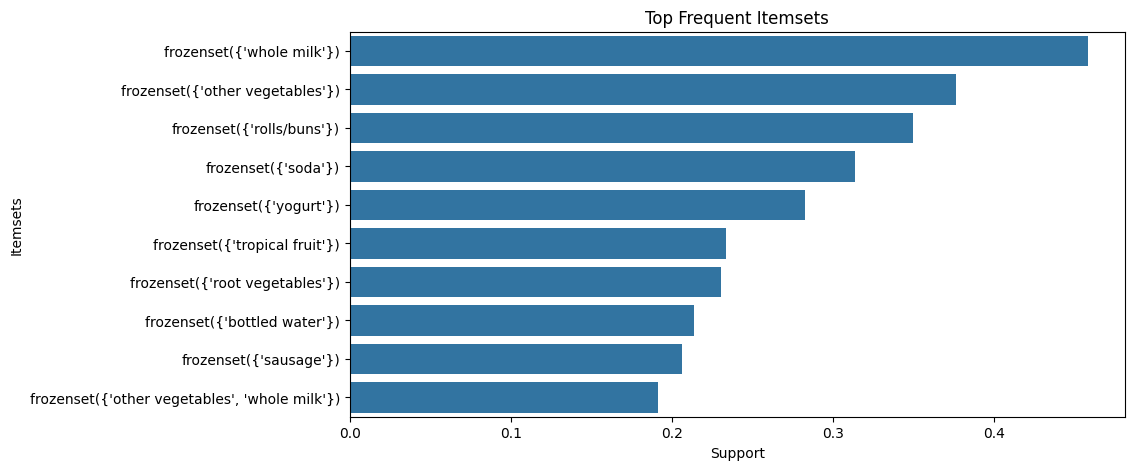

In [ ]:
top_items = frequent_itemsets.sort_values("support", ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(
    data=top_items,
    x="support",
    y=top_items["itemsets"].astype(str)   # we still convert this
)
plt.title("Top Frequent Itemsets")
plt.xlabel("Support")
plt.ylabel("Itemsets")
plt.show()

In [ ]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(UHT-milk),(other vegetables),0.078502,0.376603,0.038994,0.496732,1.318979,1.0,0.009430,1.238697,0.262440,0.093711,0.192700,0.300137
1,(UHT-milk),(rolls/buns),0.078502,0.349666,0.031042,0.395425,1.130863,1.0,0.003592,1.075687,0.125578,0.078165,0.070361,0.242100
2,(UHT-milk),(soda),0.078502,0.313494,0.027450,0.349673,1.115406,1.0,0.002840,1.055632,0.112280,0.075299,0.052700,0.218617
3,(UHT-milk),(whole milk),0.078502,0.458184,0.040534,0.516340,1.126928,1.0,0.004565,1.120242,0.122227,0.081696,0.107336,0.302403
4,(baking powder),(other vegetables),0.031042,0.376603,0.015136,0.487603,1.294740,1.0,0.003446,1.216629,0.234937,0.038562,0.178057,0.263897


In [ ]:
strong_rules = rules[
    (rules["confidence"] >= 0.5) &
    (rules["lift"] > 1.2)
]
strong_rules.sort_values("lift", ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3288,"(rolls/buns, tropical fruit, sausage)",(yogurt),0.020780,0.282966,0.011031,0.530864,1.876073,1.0,0.005151,1.528415,0.476881,0.037686,0.345728,0.284924
2837,"(sausage, whole milk, curd)",(yogurt),0.018984,0.282966,0.010005,0.527027,1.862513,1.0,0.004633,1.516016,0.472052,0.034271,0.340376,0.281193
3377,"(rolls/buns, other vegetables, whole milk, sau...",(yogurt),0.026167,0.282966,0.013597,0.519608,1.836293,1.0,0.006192,1.492602,0.467662,0.046007,0.330029,0.283829
1427,"(meat, domestic eggs)",(whole milk),0.013084,0.458184,0.010262,0.784314,1.711789,1.0,0.004267,2.512057,0.421328,0.022259,0.601920,0.403355
991,"(coffee, canned beer)",(soda),0.021036,0.313494,0.011288,0.536585,1.711628,1.0,0.004693,1.481407,0.424695,0.034921,0.324966,0.286296


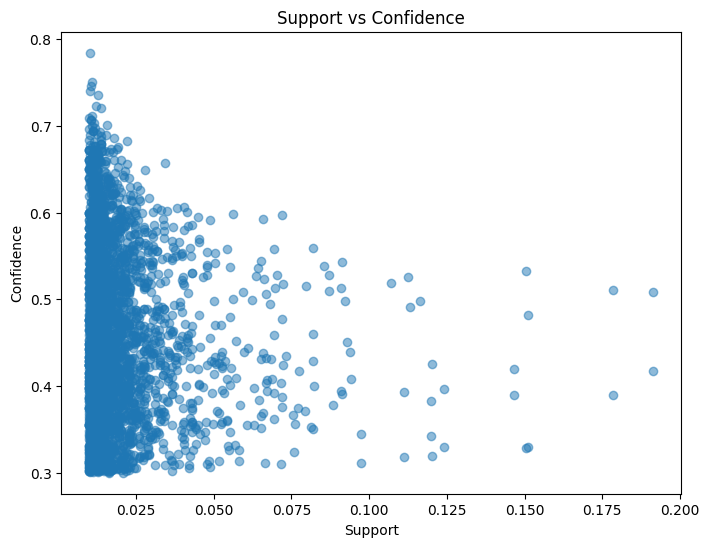

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(
    rules["support"],
    rules["confidence"],
    alpha=0.5
)
plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

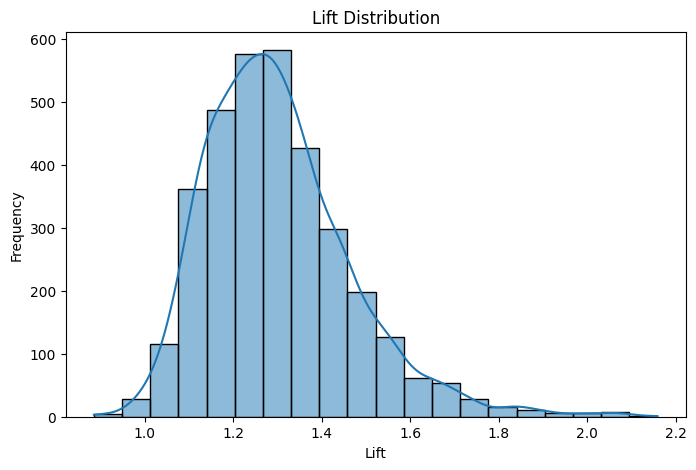

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(rules["lift"], bins=20, kde=True)

plt.title("Lift Distribution")
plt.xlabel("Lift")
plt.ylabel("Frequency")
plt.show()

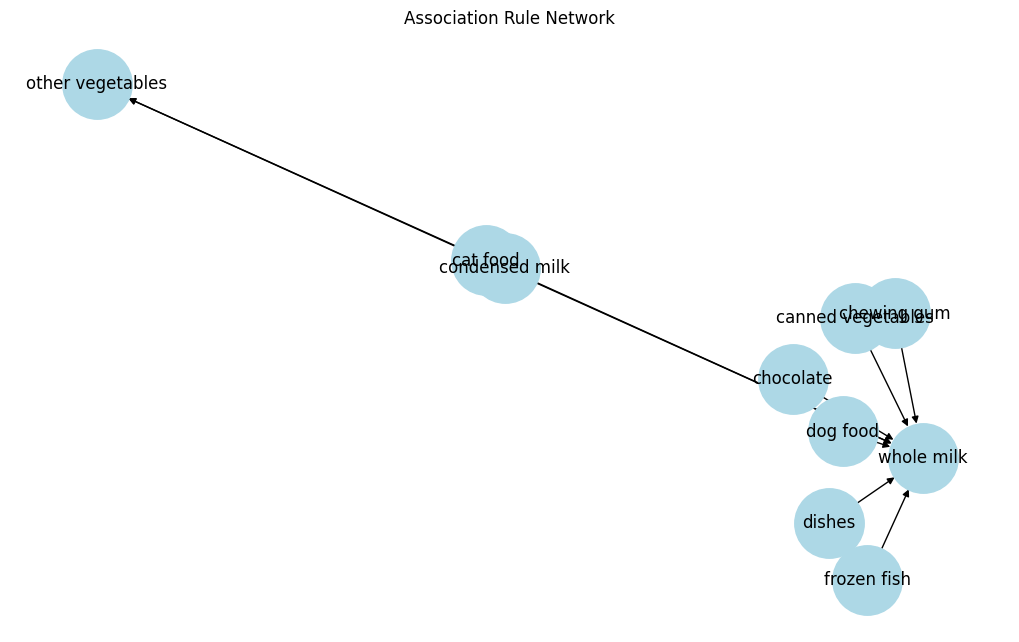

In [11]:
G = nx.DiGraph()

for _, row in strong_rules.head(10).iterrows():
    for a in row["antecedents"]:
        for c in row["consequents"]:
            G.add_edge(str(a), str(c), weight=row["lift"])

plt.figure(figsize=(10,6))
pos = nx.spring_layout(G, seed=42)

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=2500,
    node_color="lightblue",
    arrows=True
)

plt.title("Association Rule Network")
plt.show()

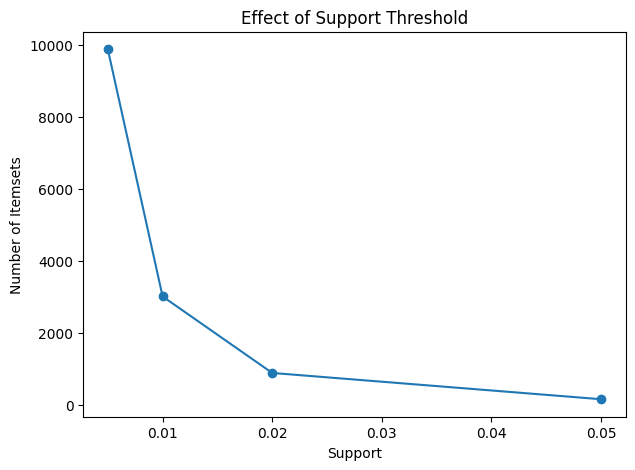

In [12]:
supports = [0.005, 0.01, 0.02, 0.05]
counts = []

for s in supports:
    temp = apriori(df_encoded, min_support=s, use_colnames=True)
    counts.append(len(temp))

plt.figure(figsize=(7,5))
plt.plot(supports, counts, marker='o')

plt.title("Effect of Support Threshold")
plt.xlabel("Support")
plt.ylabel("Number of Itemsets")
plt.show()

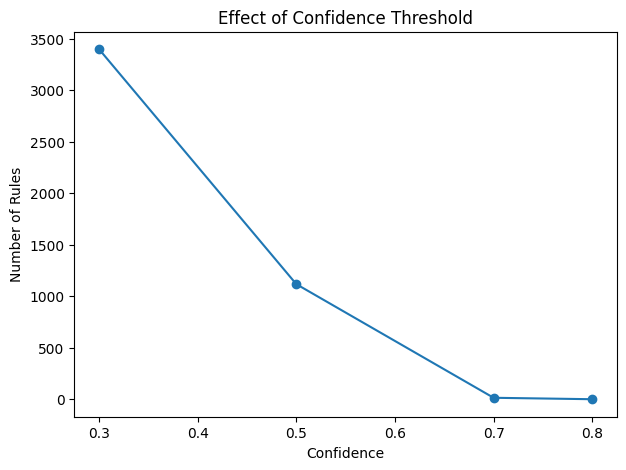

In [13]:
conf_levels = [0.3, 0.5, 0.7, 0.8]
rule_counts = []

for c in conf_levels:
    temp_rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=c)
    rule_counts.append(len(temp_rules))

plt.figure(figsize=(7,5))
plt.plot(conf_levels, rule_counts, marker='o')

plt.title("Effect of Confidence Threshold")
plt.xlabel("Confidence")
plt.ylabel("Number of Rules")
plt.show()

In [14]:
strong_rules[["antecedents", "consequents", "support", "confidence", "lift"]].head(10)

,antecedents,consequents,support,confidence,lift
67,(canned vegetables),(whole milk),0.011544,0.562500,1.227674
68,(cat food),(other vegetables),0.024115,0.549708,1.459646
72,(cat food),(whole milk),0.024371,0.555556,1.212517
77,(chewing gum),(whole milk),0.025654,0.574713,1.254328
87,(chocolate),(whole milk),0.047973,0.554896,1.211078
99,(condensed milk),(other vegetables),0.012314,0.516129,1.370484
101,(condensed milk),(whole milk),0.013853,0.580645,1.267276
127,(dishes),(whole milk),0.019497,0.571429,1.247160
128,(dog food),(whole milk),0.010005,0.582090,1.270428
148,(frozen fish),(whole milk),0.014366,0.554455,1.210116


In [15]:
rules.sort_values("lift", ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3380,"(rolls/buns, other vegetables, sausage)","(yogurt, whole milk)",0.041816,0.150590,0.013597,0.325153,2.159196,1.0,0.007300,1.258671,0.560294,0.076040,0.205511,0.207721
2898,"(whole milk, frozen meals)","(rolls/buns, other vegetables)",0.032581,0.146742,0.010005,0.307087,2.092699,1.0,0.005224,1.231407,0.539733,0.059091,0.187921,0.187634
3372,"(yogurt, rolls/buns, bottled water)","(other vegetables, whole milk)",0.026424,0.191380,0.010518,0.398058,2.079934,1.0,0.005461,1.343352,0.533308,0.050743,0.255594,0.226509
3387,"(yogurt, rolls/buns, shopping bags)","(other vegetables, whole milk)",0.025141,0.191380,0.010005,0.397959,2.079417,1.0,0.005194,1.343131,0.532483,0.048447,0.255471,0.225119
2838,"(sausage, curd)","(yogurt, whole milk)",0.032068,0.150590,0.010005,0.312000,2.071850,1.0,0.005176,1.234607,0.534479,0.057949,0.190026,0.189220
3382,"(yogurt, sausage, whole milk)","(rolls/buns, other vegetables)",0.044895,0.146742,0.013597,0.302857,2.063876,1.0,0.007009,1.223936,0.539705,0.076369,0.182964,0.197757
3390,"(yogurt, whole milk, shopping bags)","(rolls/buns, other vegetables)",0.033094,0.146742,0.010005,0.302326,2.060254,1.0,0.005149,1.223003,0.532237,0.058912,0.182341,0.185254
3381,"(yogurt, sausage, other vegetables)","(rolls/buns, whole milk)",0.037199,0.178553,0.013597,0.365517,2.047107,1.0,0.006955,1.294672,0.531268,0.067259,0.227603,0.220833
3388,"(rolls/buns, other vegetables, shopping bags)","(yogurt, whole milk)",0.032837,0.150590,0.010005,0.304688,2.023291,1.0,0.005060,1.221623,0.522927,0.057692,0.181417,0.185564
2897,"(other vegetables, frozen meals)","(rolls/buns, whole milk)",0.027707,0.178553,0.010005,0.361111,2.022430,1.0,0.005058,1.285743,0.519951,0.050980,0.222240,0.208573
